In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule

from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
import torch
import pandas as pd
import glob
import seaborn as sns

In [3]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.3f}'.format})

#### Making reliability plots with the best models from checkpoint paths

In [4]:
config = get_config()
config.device = 'cuda'
data_group, data_name = 'cevid', 'wage'
seed = 42 #choose the seed with which your model was trained on, you can look it up from the checkpoints
rc = RunConfig(config, data_group, data_name, seed = seed)
datamodule = RealDataModule(rc, num_workers=8, seed = seed)
p, q = datamodule.input_dim, datamodule.output_dim

In [6]:
#This is to automatically select checkpoints
from pathlib import Path

def find_latest_ckpt(
    log_root,
    data_group,
    data_name,
    seed,
    lam,
    prerank="none",
):
    parts = [f"model=mixture", f"seed={seed}", f"prerank={prerank}", f"lambda={lam}"]
    exp_dir_name = ",".join(parts)

    pattern = (
        Path(log_root)
        / "*"                 # any date
        / "*"                 # any time
        / data_group
        / data_name
        / exp_dir_name
        / "0"
        / "checkpoints"
        / "epoch_*.ckpt"
    )

    # Expand to full path
    ckpts = list(Path(log_root).glob(pattern.as_posix().replace(str(log_root) + "/", "")))

    if not ckpts:
        raise FileNotFoundError(f"No checkpoints found for pattern: {pattern}")

    ckpts = sorted(ckpts)        # sorts by path, which sorts timestamp folders correctly
    return ckpts[-1]             # latest ckpt from latest date, time, and highest epoch

In [73]:
log_root = "logs"

ckpt_path = find_latest_ckpt(
    log_root=log_root,
    data_group=data_group,
    data_name=data_name,
    seed=seed,
    lam=10,
    prerank="density",
    # prerank="combined",
)

print("Using checkpoint:", ckpt_path)

Using checkpoint: logs/2026-01-26/14-17-37/cevid/wage/model=mixture,seed=42,prerank=density,lambda=10/0/checkpoints/epoch_0005.ckpt


In [74]:
model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
model.eval().to(config.device)
test_loader = datamodule.test_dataloader()

In [75]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
]

model was trained on ['density'] but evaluating on ['pca', 'variance', 'density', 'cdf', 'mean', 'dependency']
Evaluating on pca


Evaluating on variance
Evaluating on density
Evaluating on cdf
Evaluating on mean
Evaluating on dependency


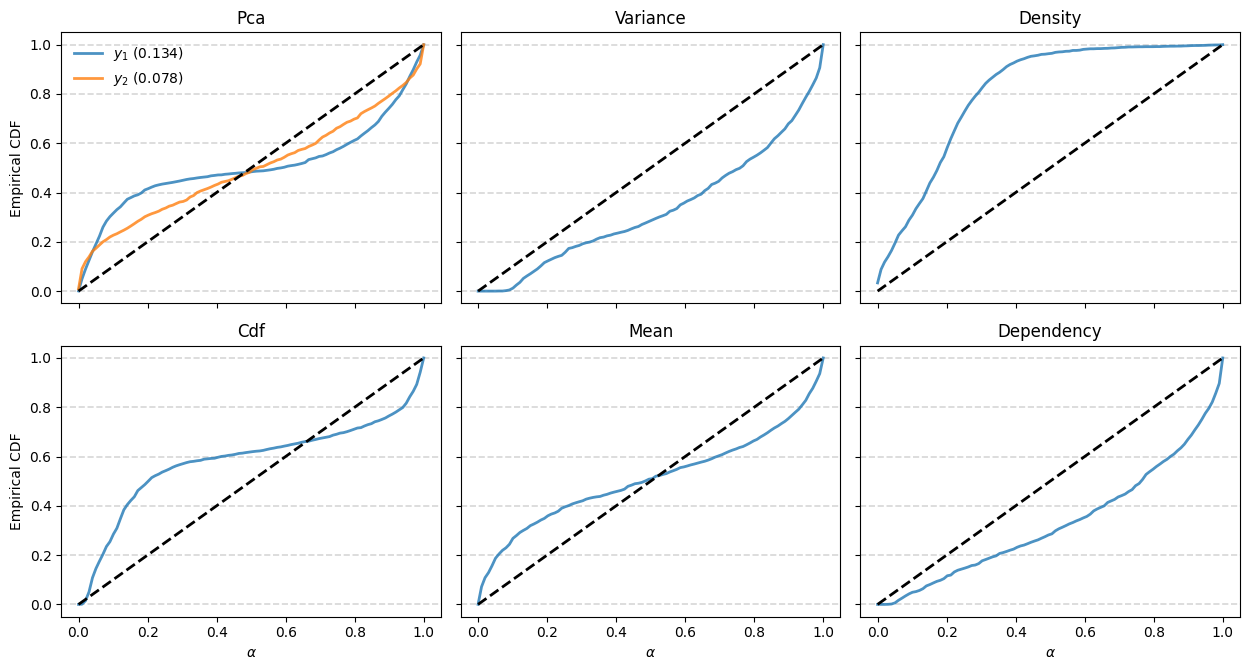

In [76]:
prerank = ['pca', 'variance', 'density', 'cdf', 'mean', 'dependency']

print(f"model was trained on {model.hparams.prerank} but evaluating on {prerank}")

ncols = 3
nrows = int(np.ceil(len(prerank) / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(4.2 * ncols, 3.4 * nrows),
    sharex=True, sharey=True
)
axes = axes.flatten()

alphas = np.linspace(0, 1, 100)

for ax, pr in zip(axes, prerank):

    print("Evaluating on", pr)
    pces, cdfs = [], []

    for x, y, idx in test_loader:
        x = x.to(config.device)
        y = y.to(config.device)

        dist = model.predict(x)
        pce_val, cdf_val = pce(
            dist, y,
            n_samples=model.hparams.es_num_samples,
            prerank=pr
        )

        pces.append(pce_val)
        cdfs.append(cdf_val)

    pce_total = torch.stack(pces).mean(dim=0)
    cdfs_total = torch.stack(cdfs).mean(dim=0)

    sorted_indices = torch.argsort(pce_total, descending=True)

    for rank, d in enumerate(sorted_indices):
        d = d.item()
        cdf = cdfs_total[d].cpu().numpy()
        label = fr"$y_{{{d+1}}}$ ({pce_total[d]:.3f})"

        ax.plot(
            alphas, cdf,
            color=colors[rank],
            lw=2, alpha=0.8,
            label=label if ax is axes[0] else None
        )

    # diagonal
    ax.plot(alphas, alphas, linestyle='--', color='black', lw=2)

    ax.set_title(pr.capitalize())
    ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth=1.2)

# axis labels (only outer)
for ax in axes[ncols:]:
    ax.set_xlabel(r'$\alpha$')
for ax in axes[::ncols]:
    ax.set_ylabel("Empirical CDF")

# legend once
axes[0].legend(loc='upper left', frameon=False)

# remove empty panels if any
for ax in axes[len(prerank):]:
    ax.axis("off")

plt.tight_layout()

os.makedirs(f"NEW_plots/{data_name}", exist_ok=True)
filename = f"NEW_plots/{data_name}/rel_plot_all_preranks_trained_on_{model.hparams.prerank[0]}.png"
plt.savefig(filename, bbox_inches="tight", dpi=300)
plt.show()

model was trained on ['variance'] but evaluating on ['marginal', 'pca', 'density', 'cdf', 'mean', 'variance', 'dependency']
Evaluating on marginal
torch.Size([16]) torch.Size([16, 100])


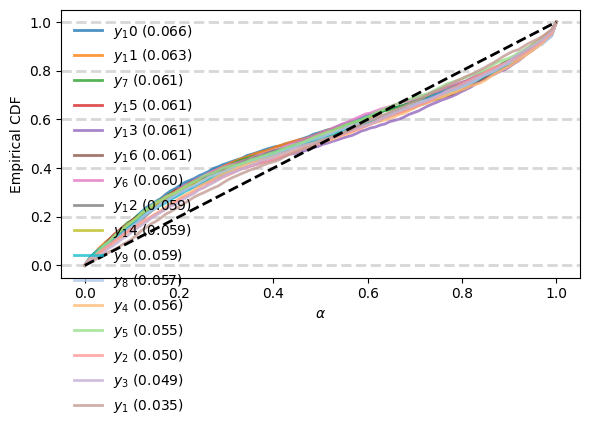

Evaluating on pca
torch.Size([2]) torch.Size([2, 100])


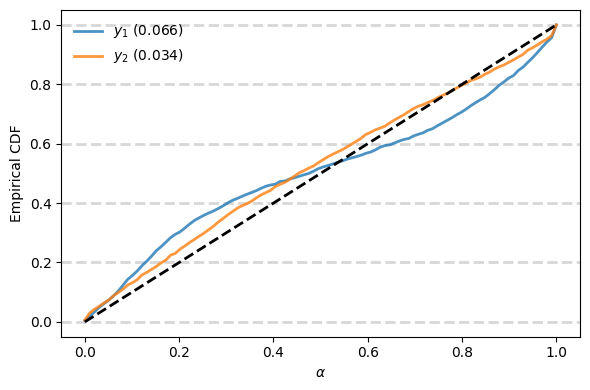

Evaluating on density
torch.Size([1]) torch.Size([1, 100])


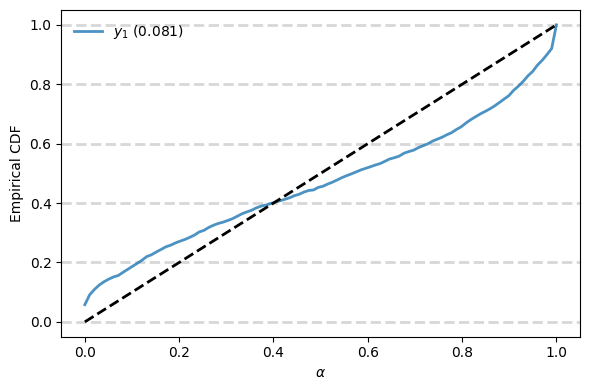

Evaluating on cdf
torch.Size([1]) torch.Size([1, 100])


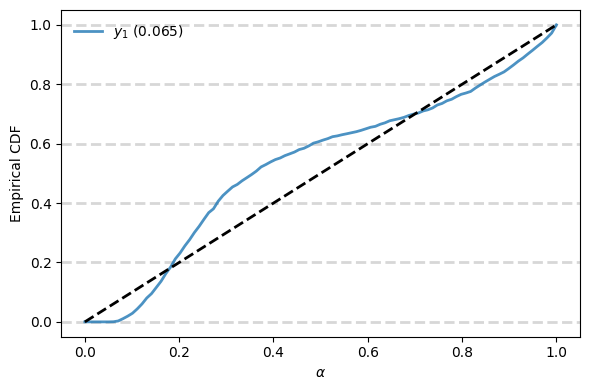

Evaluating on mean
torch.Size([1]) torch.Size([1, 100])


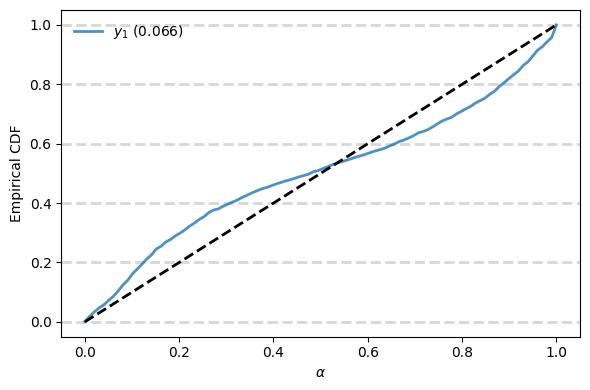

Evaluating on variance
torch.Size([1]) torch.Size([1, 100])


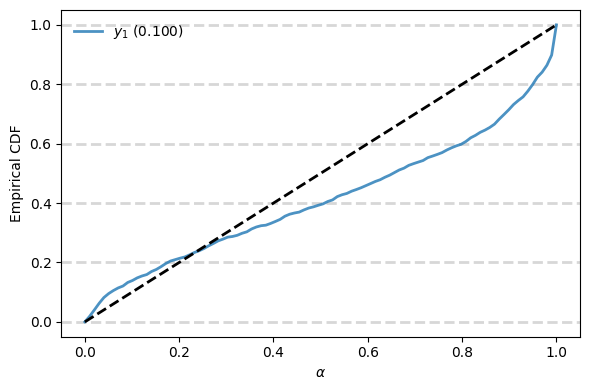

Evaluating on dependency
torch.Size([1]) torch.Size([1, 100])


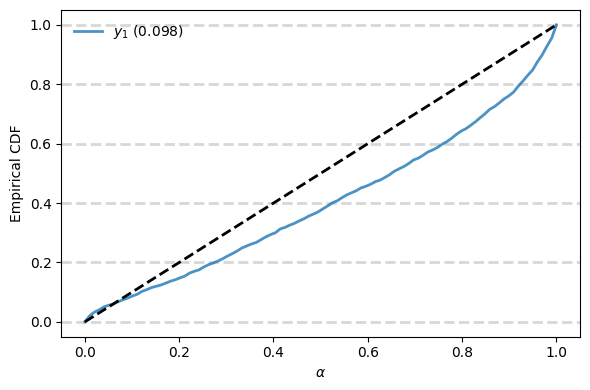

In [27]:
# pces, cdfs = [], []
prerank = ['marginal', 'pca', 'density', 'cdf', 'mean', 'variance', 'dependency']

print(f"model was trained on {model.hparams.prerank} but evaluating on {prerank}")

for pr in prerank:

    print('Evaluating on', pr)
    pces, cdfs = [], []
    for x, y, idx in test_loader:
        x = x.to(config.device)
        y = y.to(config.device)
        dist = model.predict(x)
        pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=pr)

        pces.append(pce_val)
        cdfs.append(_)
    pce_total = torch.stack(pces).mean(dim=0)
    cdfs_total = torch.stack(cdfs).mean(dim=0)
    print(pce_total.shape, cdfs_total.shape)

    alphas = np.linspace(0, 1, 100)
    sorted_indices = torch.argsort(pce_total, descending=True)

    plt.figure(figsize=(6, 4))
    for rank, d in enumerate(sorted_indices):
        d = d.item()
        cdf = cdfs_total[d].cpu().numpy()
        labelm = fr"$y_{d+1}$ ({pce_total[d]:.3f})"
        label = fr"$\rho_{{pca}}(y_1, y_2)$"

        plt.plot(alphas, cdf, color=colors[rank],
                lw=2, alpha=0.8, label=labelm)

    plt.plot(alphas, alphas, linestyle='--', color='black', lw=2)

    plt.xlabel(r'$\alpha$')
    plt.ylabel("Empirical CDF")
    plt.grid(axis='y', linestyle='--', alpha=0.5, linewidth=2)
    plt.legend(loc='upper left', frameon=False)
    plt.tight_layout()

    os.makedirs(f"NEW_plots/{data_name}", exist_ok=True)

    filename = f"NEW_plots/{data_name}/rel_plot_{pr}_trained_on_{model.hparams.prerank[0]}.png"
    plt.savefig(filename, bbox_inches = 'tight', dpi=300)
    plt.show()


    # nlls.append(nll_value.item())
    # energies.append(energy_val.item())

#### Making figures for the paper

In [26]:
import glob
import os


train_prerank = "pca"
l = 0.1
seed = 42

pattern = (
    f"logs/2026-01-19/*/{data_group}/{data_name}/"
    f"model=mixture,seed={seed},prerank={"density"},lambda={l}/0/checkpoints"
)

checkpoint_dirs = sorted(glob.glob(pattern))

print("Matched checkpoint dirs:")
for d in checkpoint_dirs:
    print(d)

Matched checkpoint dirs:
logs/2026-01-19/16-03-47/cevid/air/model=mixture,seed=42,prerank=density,lambda=0.1/0/checkpoints


In [47]:
data_group, data_name = 'cevid', 'births1'

seed = 42 #choose the seed with which your model was trained on, you can look it up from the checkpoints
rc = RunConfig(config, data_group, data_name, seed = seed)
datamodule = RealDataModule(rc, num_workers=8, seed = seed)
p, q = datamodule.input_dim, datamodule.output_dim

logs/2026-01-19/16-03-18/cevid/births1/model=mixture,seed=42,prerank=marginal,lambda=0.1/0/checkpoints


logs/2026-01-19/16-03-35/cevid/births1/model=mixture,seed=42,prerank=mean,lambda=0.1/0/checkpoints
logs/2026-01-19/16-05-20/cevid/births1/model=mixture,seed=42,prerank=variance,lambda=0.1/0/checkpoints
logs/2026-01-19/16-06-22/cevid/births1/model=mixture,seed=42,prerank=dependency,lambda=0.1/0/checkpoints
logs/2026-01-19/15-55-53/cevid/births1/model=mixture,seed=42,prerank=pca,lambda=0.1/0/checkpoints
logs/2026-01-19/16-03-47/cevid/births1/model=mixture,seed=42,prerank=density,lambda=0.1/0/checkpoints
logs/2026-01-19/16-07-33/cevid/births1/model=mixture,seed=42,prerank=cdf,lambda=0.1/0/checkpoints


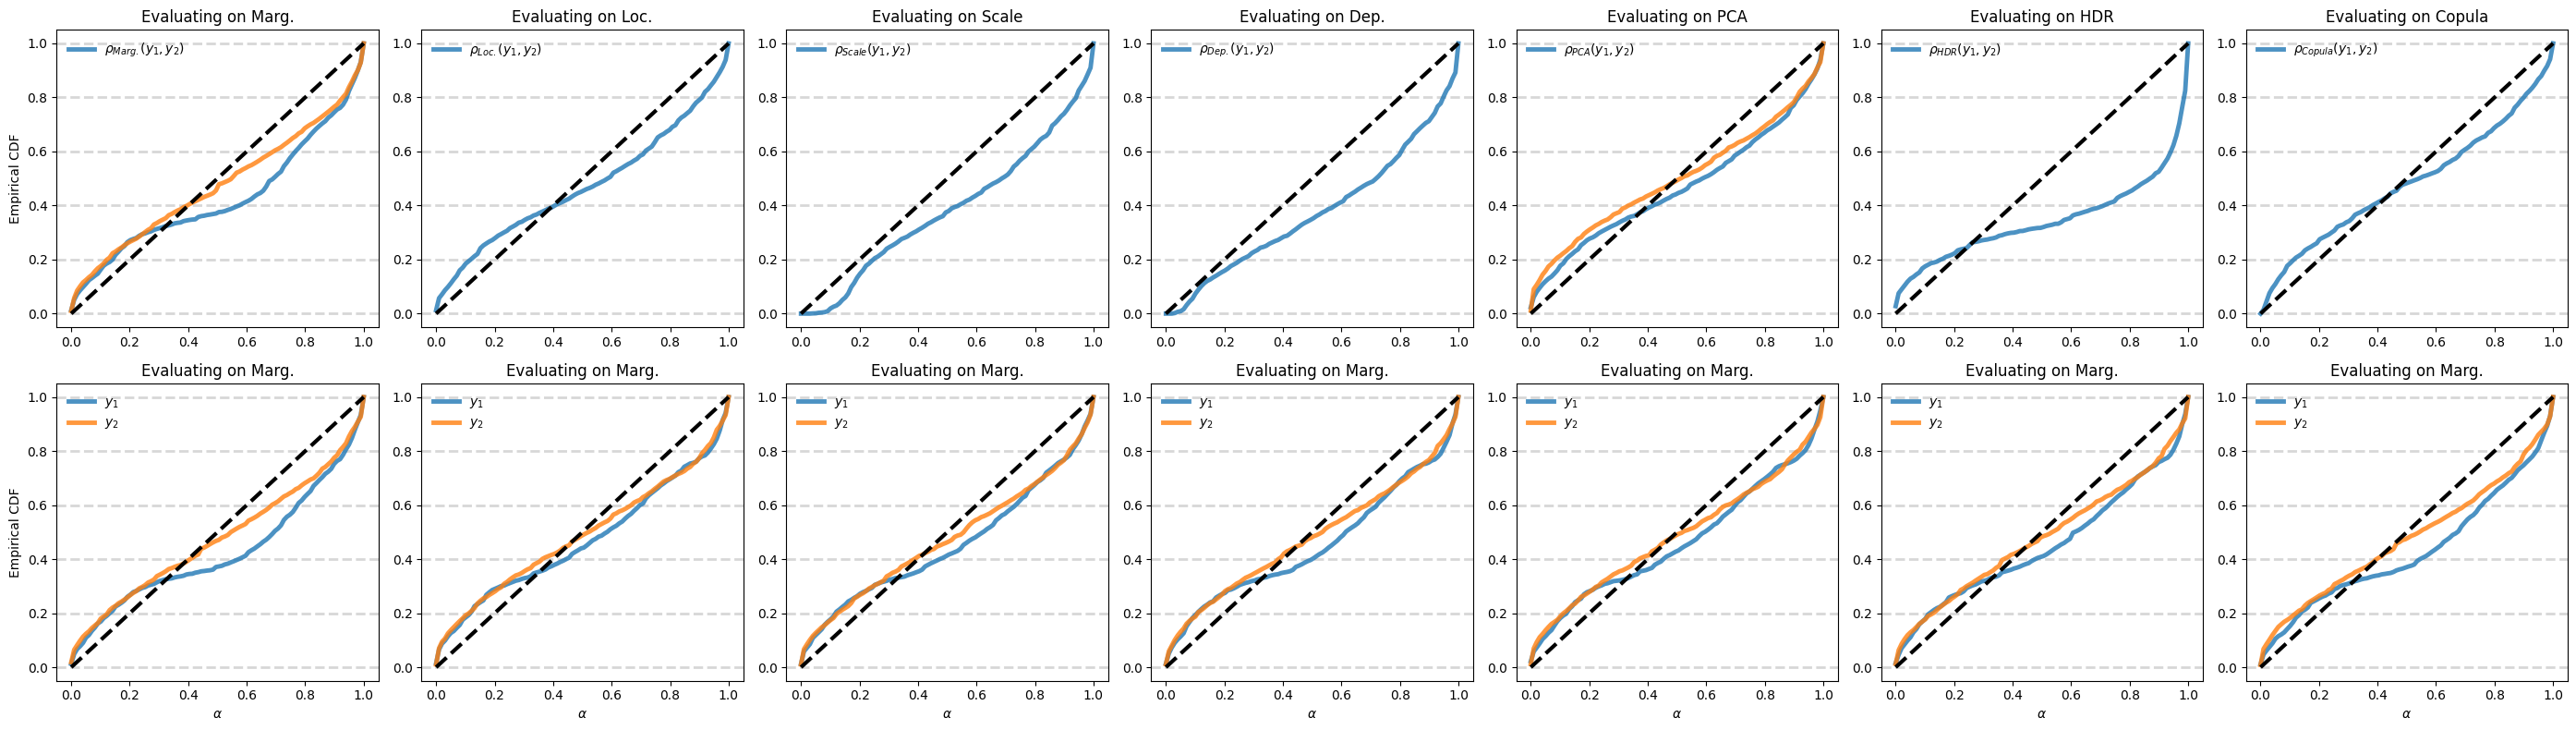

In [ ]:
custom_title = {
    "marginal": "Marg.",
    "mean": "Loc.",
    "variance": "Scale",
    "dependency": "Dep.",
    "pca": "PCA",
    "density": "HDR",
    "cdf": "Copula",
    "combined": "Comb."
}

preranks = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]

#preranks = ["combined"]   # we trained on combined preranks but evaluated on all preranks
# preranks = ["pca"]
# best_lambdas = [10.0, 10.0, 5.0, 10.0, 5.0, 1.0, 10.0]


best_lambdas = [0.1] * len(preranks)


seed = 42
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",
    "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
    "#c5b0d5", "#c49c94"
]
alphas = np.linspace(0, 1, 100)

fig, axes = plt.subplots(2, 7, figsize=(28, 8))

for col, (train_prerank, l) in enumerate(zip(preranks, best_lambdas)):

    pattern = (
    f"logs/2026-01-19/*/{data_group}/{data_name}/"
    f"model=mixture,seed={seed},prerank={train_prerank},lambda={l}/0/checkpoints"
    )

    checkpoint_dirs = sorted(glob.glob(pattern))

    # base_path = f"logs/2026-01-19/15-55-53/{data_group}/{data_name}/model=mixture,seed={seed},prerank={train_prerank},lambda={l}/0/checkpoints"
    base_path = checkpoint_dirs[0]
    print(base_path)

    ckpt_files = glob.glob(os.path.join(base_path, "*.ckpt"))
    assert ckpt_files, f"No checkpoint found in {base_path}"
    ckpt_path = ckpt_files[0]

    model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
    model.eval().to(config.device)

    test_loader = datamodule.test_dataloader()

    for i, eval_prerank in enumerate([train_prerank, "marginal"]):
        pces, cdfs = [], []
        for x, y, idx in test_loader:
            x = x.to(config.device)
            y = y.to(config.device)
            dist = model.predict(x)
            pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=eval_prerank)
            pces.append(pce_val)
            cdfs.append(_)
        pce_total = torch.stack(pces).mean(dim=0)
        cdfs_total = torch.stack(cdfs).mean(dim=0)

        ax = axes[i][col]

        vdots_shown = False
        D = cdfs_total.shape[0]
        for d in range(D):
            if i == 0:
                if q > 4:
                    y_vars = r"y_1, \dots, y_{" + str(q) + r"}"
                else:
                    y_vars = ", ".join([fr"y_{{{j+1}}}" for j in range(q)])
                label = fr"$\rho_{{{custom_title[train_prerank]}}}({y_vars})$" if d == 0 else None
            else:
                if q > 4:
                    if d == 0:
                        label = fr"$y_1$"
                    elif d == q - 1:
                        label = fr"$y_{{{q}}}$"
                    elif not vdots_shown:
                        label = fr"$\vdots$"
                        vdots_shown = True
                    else:
                        label = None
                else:
                    label = fr"$y_{{{d+1}}}$"
            ax.plot(alphas, cdfs_total[d].cpu().numpy(), color=colors[d], lw = 3.5, alpha=0.8, label=label)

        ax.plot(alphas, alphas, linestyle='--', color='black', lw = 3)

        ax.legend(loc='upper left', frameon=False)

        if i == 1:
            ax.set_xlabel(r'$\alpha$')
            ax.set_title("Evaluating on Marg.")
        if col == 0:
            ax.set_ylabel("Empirical CDF")
        ax.grid(axis='y', linestyle='--', alpha=0.5, linewidth = 2)
        if i == 0:
            ax.set_title(f"Evaluating on {custom_title[train_prerank]}")

plt.tight_layout()
plt.savefig(f"figures/NEW_plots/rel_grid_prerank_{data_name}.png", bbox_inches='tight', dpi=400)
plt.show()
# plt.close()

FileNotFoundError: No checkpoints found for pattern: logs/*/*/cevid/births1/model=mixture,seed=marginal,prerank=42,lambda=10/0/checkpoints/epoch_*.ckpt

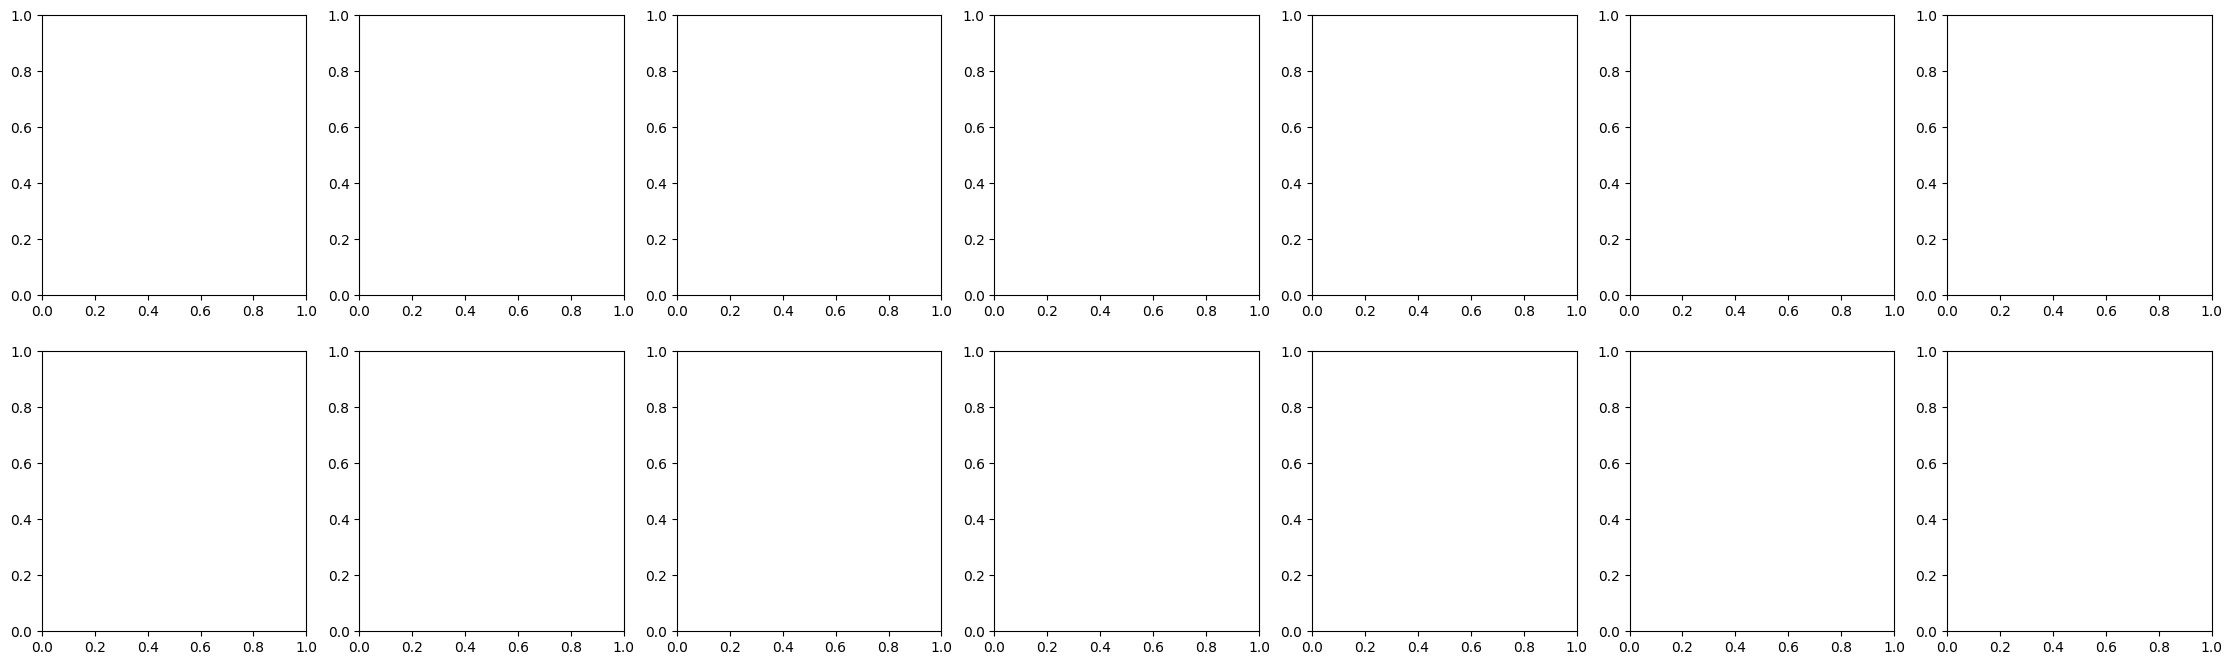

In [8]:
import os
import glob
import pandas as pd
from pathlib import Path

METRICS_LAMBDA10_CSV = Path("csv-files/FINAL-results/metrics_pca_lambda=10.csv")
DEFAULT_PRERANKS = ["marginal", "mean", "variance", "dependency", "pca", "density", "cdf"]
LAMBDA10_COLORS = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",
    "#7f7f7f", "#bcbd22", "#17becf", "#aec7e8", "#ffbb78", "#98df8a", "#ff9896",
]
CUSTOM_TITLE = {
    "marginal": "Marg.",
    "mean": "Loc.",
    "variance": "Scale",
    "dependency": "Dep.",
    "pca": "PCA",
    "density": "HDR",
    "cdf": "Copula",
    "combined": "Comb.",
}

def _best_seed_from_lambda10_metrics(data_name: str, prerank: str = "pca") -> int:
    metrics = pd.read_csv(METRICS_LAMBDA10_CSV)
    subset = metrics[(metrics["data_name"] == data_name) & (metrics["train_prerank"] == prerank)]
    if subset.empty:
        raise ValueError(f"No entries found for {data_name} and prerank={prerank} in {METRICS_LAMBDA10_CSV}")
    best_row = subset.loc[subset["pce_pca"].idxmin()]
    return int(best_row["seed"])


def _checkpoint_from_logs(data_group, data_name, train_prerank, lambda_value, seed):
    pattern = (
        f"logs/2026-01-19/*/{data_group}/{data_name}/"
        f"model=mixture,seed={seed},prerank={train_prerank}/0/checkpoints"
    )
    checkpoint_dirs = sorted(glob.glob(pattern))
    if not checkpoint_dirs:
        raise FileNotFoundError(f"No checkpoint directories found for pattern: {pattern}")
    ckpt_files = glob.glob(os.path.join(checkpoint_dirs[0], "*.ckpt"))
    if not ckpt_files:
        raise FileNotFoundError(f"No .ckpt file found in {checkpoint_dirs[0]}")
    return ckpt_files[0]


def plot_reliability_grid_from_lambda10(
    data_group,
    data_name,
    lambda_value=10,
    preranks=None,
    seed=None,
    num_workers=0,
    save_path=None,
):
    """Use the lambda=10 checkpoints collected in the CSV and reproduce the reliability grid."""
    if preranks is None:
        preranks = DEFAULT_PRERANKS
    if seed is None:
        seed = _best_seed_from_lambda10_metrics(data_name)

    cfg = get_config()
    cfg.device = "cuda" if torch.cuda.is_available() else "cpu"
    rc = RunConfig(cfg, data_group, data_name, seed=seed)
    datamodule = RealDataModule(rc, num_workers=num_workers, seed=seed)
    test_loader = datamodule.test_dataloader()
    q = datamodule.output_dim

    alphas = np.linspace(0, 1, 100)
    fig, axes = plt.subplots(2, len(preranks), figsize=(4 * len(preranks), 8))
    axes = np.atleast_2d(axes)

    for col, train_prerank in enumerate(preranks):
        ckpt_path = find_latest_ckpt(log_root,data_group, data_name, train_prerank, lambda_value, seed)
        ckpt_path = _checkpoint_from_logs(data_group, data_name, train_prerank, lambda_value, seed)
        model = MixtureLightningModule.load_from_checkpoint(ckpt_path)
        model.eval().to(cfg.device)

        for i, eval_prerank in enumerate([train_prerank, "marginal"]):
            cdfs = []
            with torch.no_grad():
                for x, y, idx in test_loader:
                    x = x.to(cfg.device)
                    y = y.to(cfg.device)
                    dist = model.predict(x)
                    n_samples = getattr(model.hparams, "es_num_samples", 100)
                    _, cdf_vals = pce(dist, y, n_samples=n_samples, prerank=eval_prerank)
                    cdfs.append(cdf_vals)
            cdfs_total = torch.stack(cdfs).mean(dim=0)
            ax = axes[i][col]
            vdots_shown = False
            D = cdfs_total.shape[0]

            for d in range(D):
                if i == 0:
                    if q > 4:
                        y_vars = r"y_1, \dots, y_{" + str(q) + r"}"
                        label = fr"$\rho_{{{CUSTOM_TITLE[train_prerank]}}}({y_vars})$" if d == 0 else None
                    else:
                        y_vars = ", ".join([fr"y_{{{j+1}}}" for j in range(q)])
                        label = fr"$\rho_{{{CUSTOM_TITLE[train_prerank]}}}({y_vars})$" if d == 0 else None
                else:
                    if q > 4:
                        if d == 0:
                            label = fr"$y_1$"
                        elif d == q - 1:
                            label = fr"$y_{{{q}}}$"
                        elif not vdots_shown:
                            label = fr"$\vdots$"
                            vdots_shown = True
                        else:
                            label = None
                    else:
                        label = fr"$y_{{{d+1}}}$"
                ax.plot(
                    alphas,
                    cdfs_total[d].cpu().numpy(),
                    color=LAMBDA10_COLORS[d % len(LAMBDA10_COLORS)],
                    lw=3.5,
                    alpha=0.8,
                    label=label,
                )
            ax.plot(alphas, alphas, linestyle="--", color="black", lw=3)
            ax.legend(loc="upper left", frameon=False)
            if i == 1:
                ax.set_xlabel(r"$\alpha$")
                ax.set_title("Evaluating on Marg.")
            if col == 0:
                ax.set_ylabel("Empirical CDF")
            ax.grid(axis="y", linestyle="--", alpha=0.5, linewidth=2)
            if i == 0:
                ax.set_title(f"Evaluating on {CUSTOM_TITLE[train_prerank]}")

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=400)
    plt.show()
    return fig, axes

# Example:
log_root = "logs"
plot_reliability_grid_from_lambda10("cevid", "births1")

In [ ]:
print('inserted cell')

# Comparison between reg and non reg metrics 

#### Making box plots for PCE, NLL, Energy Score, MSE before and after reg (with prerank only for now)

Metrics without prerank regularization

## Comparison and plotting function

In [18]:
def compare_calibration_methods(df1, df2, label1="Without Regularization", label2="With Regularization", save_name=None):
    palette = {label1: '#E8505B', label2: '#4A90E2'}
    prerank_labels = {'pce_marginal': 'Marginal', 'pce_mean': 'Mean', 'pce_variance': 'Variance',
                      'pce_dependency': 'Dependency', 'pce_pca': 'PCA', 'pce_density': 'Density', 'pce_cdf': 'CDF'}
    order = [prerank_labels[c] for c in prerank_labels if c in df1.columns or c in df2.columns]

    def prep(df, lbl):
        cols = [c for c in prerank_labels if c in df.columns]
        long = df.melt(id_vars="data_name", value_vars=cols, var_name="prerank", value_name="score")
        long["source"] = lbl
        long["prerank"] = long["prerank"].map(prerank_labels)
        long = long.dropna(subset=["prerank"])
        long["prerank"] = pd.Categorical(long["prerank"], categories=order, ordered=True)
        return long

    to_plot = pd.concat([prep(df1, label1), prep(df2, label2)], ignore_index=True)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


    flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#676B70', markersize=4, linestyle='none') #outliers


    # Panel 1: Box plot comparing distributions
    box = sns.boxplot(data=to_plot, x="prerank", y="score", hue="source", palette=palette, order=order,
                hue_order=[label1, label2], ax=ax1, linewidth=1.2, flierprops=flierprops)


    ax1.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax1.set_ylabel('PCE Score', fontweight='bold', fontsize=11)
    ax1.set_title('(a) Distribution Across Datasets', loc='left', fontweight='bold', fontsize=12)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax1.legend(frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)

    # Panel 2: Mean reduction per prerank with error bars
    summary = to_plot.groupby(['prerank', 'source'], observed=True)['score'].agg(mean='mean', sem='sem').reset_index()
    mean_p = summary.pivot(index='prerank', columns='source', values='mean').reindex(order)
    sem_p = summary.pivot(index='prerank', columns='source', values='sem').reindex(order)
    reduction = (1 - mean_p[label2] / mean_p[label1]) * 100

    x = np.arange(len(order))
    width = 0.30
    offset = width / 2 + 0.02
    bar_kws = dict(width=width, alpha=0.9, edgecolor='white', linewidth=0.5,
                   error_kw={'linewidth': 1.2, 'capsize': 4})
    ax2.bar(x - offset, mean_p[label1], yerr=sem_p[label1], label=label1, color=palette[label1], **bar_kws)
    ax2.bar(x + offset, mean_p[label2], yerr=sem_p[label2], label=label2, color=palette[label2], **bar_kws)

    ax2.set_xlabel('Pre-rank Type', fontweight='bold', fontsize=11)
    ax2.set_ylabel('Mean PCE (± SEM)', fontweight='bold', fontsize=11)
    ax2.set_title('(b) Systematic Reduction', loc='left', fontweight='bold', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(order, rotation=30, ha='right')
    ax2.legend(frameon=True, loc='upper left', edgecolor='gray', framealpha=0.95)

    for ax in (ax1, ax2):
        ax.grid(axis='y', alpha=0.25, linestyle='--')
        ax.set_axisbelow(True)

    for i, (pct, val) in enumerate(zip(reduction, mean_p[label1])):
        if pd.notna(pct) and pct > 0:
            ax2.text(i, val + 0.01, f'−{pct:.0f}%', ha='center', va='bottom', fontsize=9,
                     fontweight='bold', color='#2c3e50')

    plt.tight_layout()
    if save_name:
        for ext in ['.pdf', '.png']:
            plt.savefig(f'figures/paper/{save_name}{ext}', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Average calibration error reduction: {reduction[reduction > 0].mean():.1f}%")


In [5]:
df_without_reg = pd.read_csv('csv-files/metrics-from-model-without-reg.csv')
df_without_reg.head()

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,0,3.418154,0.951700,0.100673,0.101714,0.137847,0.021739,0.071630,0.096383,0.150327,0.654726
1,households,42,3.113848,0.930611,0.107735,0.102612,0.124320,0.024782,0.072907,0.076950,0.167739,0.635204
2,households,866,3.175431,0.921504,0.099934,0.097004,0.116293,0.019058,0.066167,0.079132,0.162383,0.628146
3,households,12,3.252299,0.910707,0.106252,0.104194,0.130166,0.023124,0.074484,0.094715,0.173448,0.604590
4,households,4,3.126510,0.899053,0.103187,0.108343,0.107593,0.023114,0.072891,0.095386,0.161886,0.601537


In [6]:
avg_df_without_reg = df_without_reg.groupby(['data_name'], sort=False).mean().reset_index()
avg_df_without_reg = avg_df_without_reg.drop(columns=['seed'])
avg_df_without_reg.head()

,data_name,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,3.217248,0.922715,0.103556,0.102773,0.123244,0.022364,0.071616,0.088513,0.163157,0.624841
1,air,5.601876,1.404634,0.098625,0.095551,0.206735,0.054538,0.074462,0.083278,0.155364,0.926101
2,births1,1.264864,0.711053,0.081726,0.081459,0.107733,0.109782,0.077794,0.181749,0.071155,0.845310
3,births2,-4.694013,0.888976,0.198942,0.056111,0.069322,0.077578,0.120436,0.414213,0.210421,0.832173
4,wage,0.461110,0.700426,0.132236,0.085333,0.108759,0.111032,0.114262,0.415032,0.141996,0.710224


In [7]:
df_combined_ALL = pd.read_csv('csv-files/metrics-from-model-trained-on-marginal_mean_variance_dependency_pca.csv')
df_combined_ALL.head()

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,0,3.354815,0.947328,0.087885,0.090055,0.132603,0.023052,0.071283,0.143207,0.137216,0.651467
1,households,42,3.204756,0.923683,0.097642,0.087059,0.114546,0.021070,0.069150,0.088145,0.157456,0.631581
2,households,866,3.165882,0.920997,0.094263,0.095354,0.124890,0.019297,0.068902,0.111912,0.147745,0.624626
3,households,12,3.169688,0.909942,0.092092,0.085098,0.123834,0.024930,0.064489,0.104703,0.153319,0.597962
4,households,4,3.124319,0.907215,0.092524,0.097382,0.096281,0.019272,0.067868,0.086552,0.147716,0.609711


In [8]:
avg_df_combined_ALL = df_combined_ALL.groupby(['data_name'], sort=False).mean().reset_index()
avg_df_combined_ALL = avg_df_combined_ALL.drop(columns=['seed'])
avg_df_combined_ALL.head()

,data_name,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,3.203892,0.921833,0.092881,0.090990,0.118431,0.021524,0.068338,0.106904,0.148690,0.623069
1,air,5.635381,1.402522,0.089935,0.084332,0.189339,0.049280,0.068685,0.076905,0.138811,0.920388
2,births1,1.217848,0.712923,0.071040,0.070299,0.094652,0.096379,0.070819,0.180432,0.062357,0.844687
3,births2,-1.547774,0.892244,0.190879,0.039862,0.057242,0.069678,0.120967,0.411954,0.206117,0.850584
4,wage,0.372805,0.704837,0.129849,0.080629,0.092274,0.094199,0.116130,0.418324,0.136786,0.713036


In [9]:
df_with_simple_reg = pd.read_csv('csv-files/metrics-from-model-trained-on-train_prerank=marginal.csv')
df_with_simple_reg.head()

,data_name,seed,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,0,3.353530,0.936195,0.095459,0.096671,0.124002,0.024888,0.069413,0.119168,0.144964,0.639075
1,households,42,3.197253,0.929397,0.103963,0.099142,0.123355,0.023692,0.067107,0.073127,0.165900,0.630316
2,households,866,3.301141,0.941861,0.091401,0.091054,0.128674,0.019905,0.070981,0.093111,0.141610,0.653524
3,households,12,3.170550,0.912762,0.101071,0.099134,0.126619,0.022816,0.068140,0.094977,0.157515,0.610481
4,households,4,3.159369,0.906625,0.100524,0.099796,0.124294,0.020535,0.071699,0.101524,0.158583,0.608289


In [10]:
avg_df_with_simple_reg = df_with_simple_reg.groupby(['data_name'], sort=False).mean().reset_index()
avg_df_with_simple_reg = avg_df_with_simple_reg.drop(columns=['seed'])
avg_df_with_simple_reg.head()

,data_name,nll,energy,pce_marginal,pce_mean,pce_variance,pce_dependency,pce_pca,pce_density,pce_cdf,mse
0,households,3.236369,0.925368,0.098483,0.097159,0.125389,0.022367,0.069468,0.096381,0.153714,0.628337
1,air,5.546631,1.405240,0.097674,0.092063,0.203845,0.054359,0.075013,0.082815,0.152441,0.929100
2,births1,1.171418,0.710208,0.074923,0.075984,0.107656,0.109406,0.075221,0.202418,0.065425,0.846072
3,births2,-4.553977,0.889860,0.197263,0.050389,0.063682,0.072161,0.122557,0.419526,0.215810,0.842578
4,wage,0.508649,0.713055,0.133421,0.082816,0.107575,0.108004,0.116347,0.412587,0.141279,0.723910


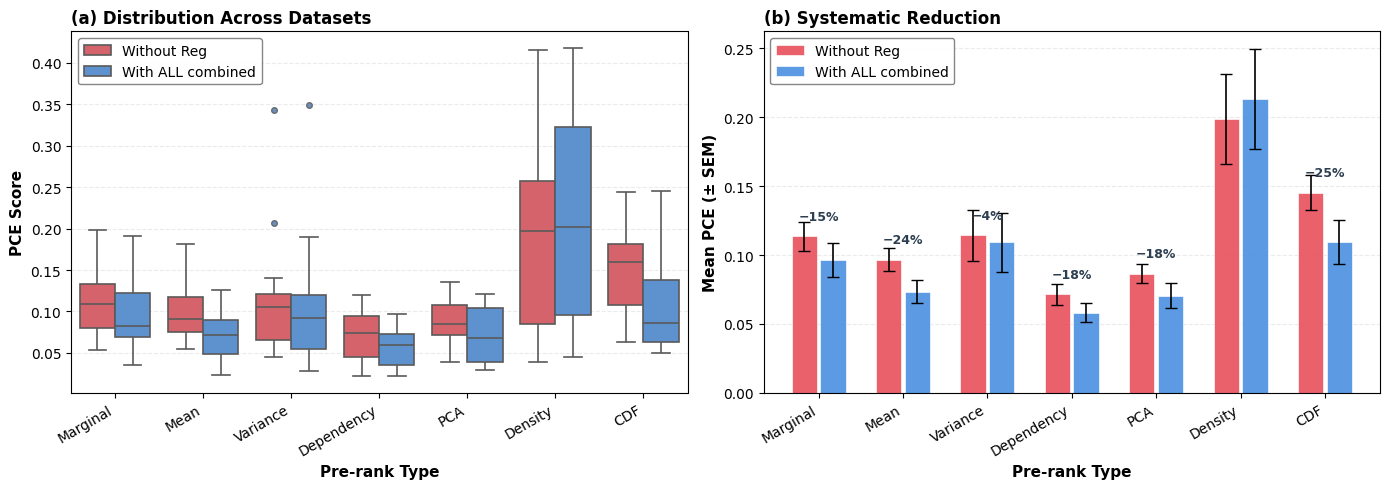

Average calibration error reduction: 17.6%


In [19]:
compare_calibration_methods(avg_df_without_reg, avg_df_combined_ALL, label1="Without Reg", label2="With ALL combined")

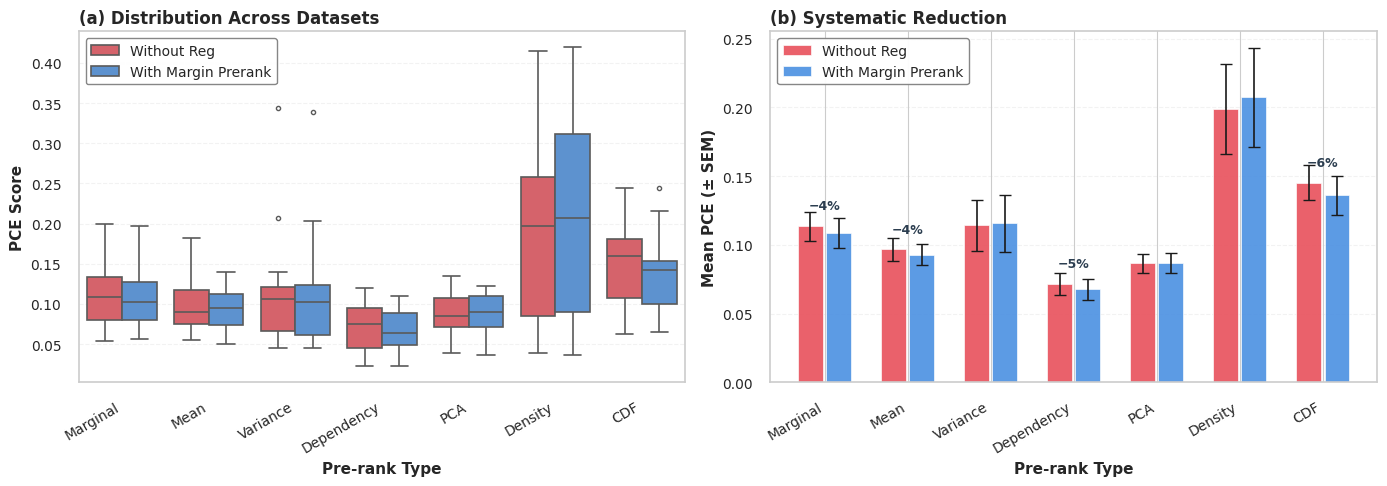

Average calibration error reduction: 4.9%


In [56]:
compare_calibration_methods(avg_df_without_reg, avg_df_with_simple_reg, label1="Without Reg", label2="With Margin Prerank")

## Previous plots :

In [ ]:
df = pd.read_csv('metrics-after-reg.csv')
df.head()

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.028741,3.295859,0.951055,0.663382
1,households,42,marginal,0.031749,3.270183,0.882693,0.554523
2,households,866,marginal,0.029671,3.396923,0.965792,0.652964
3,households,12,marginal,0.029982,3.423873,0.960883,0.667672
4,households,4,marginal,0.027437,3.255520,0.935410,0.623558


In [ ]:
avg_df = df.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df = avg_df[~avg_df['data_name'].isin(['rf1', 'rf2', 'sf2'])]
avg_df.shape

(126, 6)

In [ ]:
# df_before = pd.read_csv('metrics-before-reg.csv')
# df_before = df_before[~df_before['data_name'].isin(['rf1', 'rf2', 'sf2'])]
df_hdr = pd.read_csv('metrics-hdr.csv')
df_hdr = df_hdr[~df_hdr['data_name'].isin(['rf1', 'rf2', 'sf2'])]

In [34]:
df_hdr = pd.read_csv('metrics-hdr.csv')
df_hdr

,data_name,prerank,pce,energy,nll
0,households,marginal,0.025537,0.946943,3.286228
1,households,mean,0.018683,0.946145,3.286228
2,households,variance,0.020806,0.942322,3.286228
3,households,dependency,0.019679,0.949163,3.286228
4,households,pca,0.020114,0.945214,3.286228
...,...,...,...,...,...
121,taxi,variance,0.025650,0.685726,1.675086
122,taxi,dependency,0.022429,0.684384,1.675086
123,taxi,pca,0.021144,0.685127,1.675086
124,taxi,density,0.020719,0.684548,1.675086


In [ ]:
# avg_df_before = df_before.groupby(['data_name', 'prerank'], sort = False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
# avg_df_before = avg_df_before.groupby('data_name', sort=False)[['nll', 'energy', 'mse']].mean().reset_index()
# avg_df_before.shape
df_hdr.shape

(126, 4)

In [ ]:
df_hdr.head()

,data_name,prerank,pce,energy
0,households,marginal,0.028337,0.952953
1,households,mean,0.027010,0.947334
2,households,variance,0.026152,0.952341
3,households,dependency,0.022940,0.949789
4,households,pca,0.022417,0.953044


In [ ]:
avg_df.head(7)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
5,households,density,0.038680,3.292781,0.932650,0.628786
6,households,cdf,0.030640,3.354427,0.952433,0.658789


In [ ]:
datasets = df_hdr['data_name'].unique()
avg_df_filtered = avg_df[avg_df['data_name'].isin(datasets)]

# 3. keep only relevant columns
df_ours = avg_df_filtered[['data_name', 'prerank', 'pce', 'energy']]

In [ ]:
avg_scores_per_data = avg_df_before.groupby('data_name', sort=False)[['nll', 'energy', 'mse']].mean().reset_index()
avg_scores_per_data['prerank'] = 'none'
avg_scores_per_data['pce'] = 0
avg_scores_per_data.head()

,data_name,nll,energy,mse,prerank,pce
0,households,3.187087,0.918165,0.614488,none,0
1,air,5.650568,1.397655,0.937892,none,0
2,births1,1.181293,0.682644,0.759425,none,0
3,births2,-4.447253,0.922516,1.067480,none,0
4,wage,0.511141,0.711580,0.727497,none,0


In [ ]:
# Define custom order: "none" first, then the rest (sorted or explicitly ordered)
prerank_order = ['none', 'marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']

# Concat the two DataFrames
combined = pd.concat([avg_df, avg_scores_per_data], ignore_index=True)

# Convert 'prerank' column to categorical with desired order
combined['prerank'] = pd.Categorical(combined['prerank'], categories=prerank_order, ordered=True)

# Sort by dataset and then prerank
combined = combined.sort_values(['data_name', 'prerank']).reset_index(drop=True)
combined.head(8)

,data_name,prerank,pce,nll,energy,mse
0,air,none,0.000000,5.650568,1.397655,0.937892
1,air,marginal,0.039892,5.798495,1.421109,0.950752
2,air,mean,0.026328,5.812055,1.427127,0.949652
3,air,variance,0.026756,5.750404,1.417962,0.956134
4,air,dependency,0.026949,5.712583,1.405788,0.948559
5,air,pca,0.039238,5.787327,1.416858,0.944779
6,air,density,0.044818,5.666744,1.405010,0.942634
7,air,cdf,0.029004,5.798847,1.435200,0.993631


In [ ]:
plt.rcParams.update({'font.size': 10})
import matplotlib.patches as mpatches

In [ ]:
# Step 1: get only 'density' rows
density_df = df_ours[df_ours['prerank'] == 'density']

# Step 2: find top 4 datasets with highest PCE
top4 = density_df.nlargest(4, 'pce')['data_name']

# Step 3: remove those datasets entirely (all their preranks)
filtered_df_ours = df_ours[~df_ours['data_name'].isin(top4)]


In [39]:
df = pd.read_csv('csv-files/sensitivity-s.csv')
# find top-4 datasets with highest PCE for density prerank
bad_datasets = (
    df[df["prerank"] == "density"]
    .groupby("data_name")["pce"]
    .mean()
    .nlargest(4)
    .index
)

# drop them
df_filtered = df[~df["data_name"].isin(bad_datasets)]

In [40]:
# df_filtered['total_train_time'] = df_filtered['total_train_time']/60

df_filtered

,data_name,s,prerank,pce,nll,energy,total_train_time,total_inference_time
0,households,100,marginal,0.029680,3.343005,0.963094,2.956841,0.010007
1,households,1000,marginal,0.028360,3.412562,0.949776,4.150700,0.008688
2,households,100,mean,0.022471,3.388291,0.976821,2.390759,0.007942
3,households,1000,mean,0.022863,3.427808,0.962650,3.545921,0.010102
4,households,100,variance,0.025930,3.341262,0.949836,2.867810,0.008617
...,...,...,...,...,...,...,...,...
239,taxi,1000,marginal,0.023184,1.779943,0.698208,9.609548,0.017490
240,taxi,100,mean,0.028397,1.772177,0.693174,12.542973,0.015937
241,taxi,1000,mean,0.026427,1.771131,0.691958,14.361399,0.017349
242,taxi,100,variance,0.025559,1.775373,0.691759,14.242337,0.015300


In [41]:
# df = pd.read_csv('csv-files/sensitivity-s.csv')
# # find top-4 datasets with highest PCE for density prerank
# bad_datasets = (
#     df[df["prerank"] == "density"]
#     .groupby("data_name")["pce"]
#     .mean()
#     .nlargest(4)
#     .index
# )

# # drop them
# df_filtered = df[~df["data_name"].isin(bad_datasets)]

# now split
df_100 = df_filtered[df_filtered["s"] == 100].reset_index(drop=True)
df_1000 = df_filtered[df_filtered["s"] == 1000].reset_index(drop=True)

In [42]:
# merge on dataset + prerank
merged = df_100.merge(df_1000, on=["data_name", "prerank"], suffixes=("_100", "_1000"))

# compute training time difference
merged["train_time_diff"] = merged["total_train_time_1000"] - merged["total_train_time_100"]

# average per prerank
summary = merged.groupby("prerank")["train_time_diff"].mean().reset_index()

# global average
global_avg = merged["train_time_diff"].mean()

print(summary)
print("Global average training time difference:", global_avg)

      prerank  train_time_diff
0         cdf       378.031577
1     density       237.790808
2  dependency         0.399338
3    marginal        -0.810882
4        mean        -0.350225
5         pca         2.656439
6    variance        -1.635281
Global average training time difference: 85.17304970007919


In [43]:
# pivot so each row = dataset + prerank, columns = s values
pivot = df_filtered.pivot_table(
    index=["data_name", "prerank"],
    columns="s",
    values="pce"
).reset_index()

# rename for clarity
pivot = pivot.rename(columns={100: "pce_100", 1000: "pce_1000"})

# relative change: negative = improvement, positive = worse
pivot["pce_rel_change_%"] = (pivot["pce_100"] - pivot["pce_1000"]) / pivot["pce_1000"] * 100

# compute summary per prerank
summary = pivot.groupby("prerank")["pce_rel_change_%"].agg(
    median="median",
    mean="mean",
    improved=lambda x: (x > 0).sum(),
    worsened=lambda x: (x < 0).sum()
).reset_index()

print(summary)

      prerank    median      mean  improved  worsened
0         cdf  0.785964 -0.373381         7         6
1     density  0.453016 -6.087444         7         6
2  dependency  0.786801  0.717363         8         5
3    marginal  0.450979 -0.092283         7         7
4        mean  1.160882 -0.914062         8         6
5         pca  0.602812  1.881555         7         6
6    variance -3.071575 -3.197484         6         8


In [44]:
pivot.head(7)

s,data_name,prerank,pce_100,pce_1000,pce_rel_change_%
0,air,cdf,0.029199,0.030797,-5.187565
1,air,density,0.030475,0.031136,-2.122961
2,air,dependency,0.026837,0.027617,-2.827093
3,air,marginal,0.038037,0.039659,-4.089258
4,air,mean,0.029431,0.027317,7.739357
5,air,pca,0.034833,0.038817,-10.264448
6,air,variance,0.023774,0.024122,-1.440139


In [45]:
len(df_100.data_name.unique())

14

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

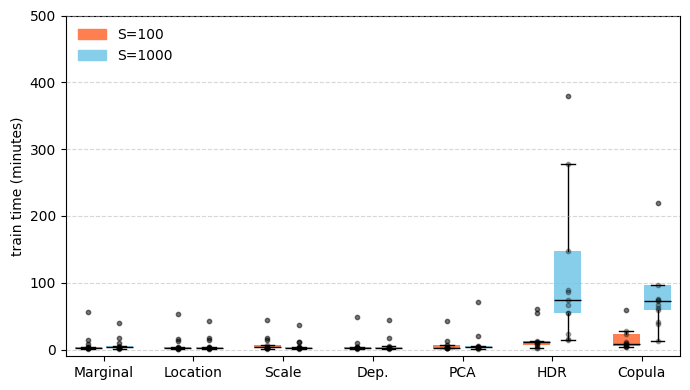

In [53]:
preranks = df_filtered['prerank'].unique()
labels = ["Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"]

gap = 2.0      # space between prerank groups
delta = 0.7    # spacing between before and after in same group

data = []
xticks = []
positions = []

for i, p in enumerate(preranks):
    base = i * gap
    positions.extend([base, base + delta])  # before, after
    xticks.append(base + delta / 2)
    pce_100 = df_100[df_100['prerank'] == p]['total_train_time'].values
    pce_1000 = df_1000[df_1000['prerank'] == p]['total_train_time'].values
    # diff = np.abs(pce_before - pce_after)
    # data.append(diff)
    data.append(pce_100)
    data.append(pce_1000)

plt.figure(figsize=(7, 4))

box = plt.boxplot(data, positions=positions, widths=0.6, patch_artist=True, zorder=2,
                  flierprops=dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3),
                  meanline=True, boxprops=dict(color='none'))


for i, patch in enumerate(box['boxes']):
    if i % 2 == 0:
        patch.set_facecolor("coral")  # before: orange opaque
    else:
        patch.set_facecolor("skyblue")  # after: blue opaque

for median in box['medians']:
    median.set_linewidth(1)
    median.set_color("black")

# scatter the points
for i, d in enumerate(data):
    x = [positions[i]] * len(d)
    plt.scatter(x, d, color='black', s=10, zorder=3, alpha=0.3)

orange_patch = mpatches.Patch(color="coral", label='S=100')
blue_patch = mpatches.Patch(color="skyblue", label='S=1000')

plt.ylim(-10, 500)

plt.xticks(xticks, labels)
plt.ylabel("train time (minutes)")
plt.legend(handles=[orange_patch, blue_patch], loc='upper left', frameon=False)
plt.gca().set_axisbelow(False)
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=4)
plt.tight_layout()
plt.savefig(f"box_plot_s=100_s=1000_train_time.pdf", bbox_inches='tight', dpi=500)
plt.show()

In [ ]:
avg_df_before = df_before.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df_before.head(10)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
5,households,density,0.097097,3.187087,0.917767,0.614488
6,households,cdf,0.149487,3.187087,0.916933,0.614488
7,air,marginal,0.099014,5.650568,1.397020,0.937892
8,air,mean,0.092714,5.650568,1.396897,0.937892
9,air,variance,0.198090,5.650568,1.400152,0.937892


In [ ]:
grouped = avg_df_before.groupby("data_name")[["nll", "energy", "mse"]].mean().reset_index()
grouped = grouped[~grouped['data_name'].isin(['rf1', 'rf2', 'sf2'])]

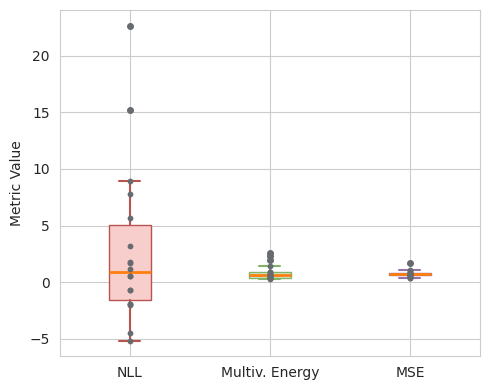

In [ ]:
plt.figure(figsize=(5, 4))

flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#676B70', markersize=4, linestyle='none') #outliers
box = plt.boxplot([grouped[col].values for col in ["nll", "energy", "mse"]],
                  patch_artist=True, tick_labels=["NLL", "Multiv. Energy", "MSE"], flierprops=flierprops)

for patch in box['boxes']:
    patch.set_facecolor("#DAE8FC")
    patch.set_edgecolor("#6C8EBF")

colors = ['#F8CECC', '#D5E8D4', '#E1D5E7']  # one color per box
edge_colors = ['#B85450', "#82B366", "#9673A6"]
for patch, color, edge in zip(box['boxes'], colors, edge_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(edge)  # optional

for median in box['medians']:
    median.set_linewidth(2)

for i, edge in enumerate(edge_colors):
    box['caps'][2*i].set_color(edge)     # bottom cap
    box['caps'][2*i + 1].set_color(edge) # top cap
    box['caps'][2*i].set_linewidth(1.5)
    box['caps'][2*i+1].set_linewidth(1.5)

for i, edge in enumerate(edge_colors):
    box['whiskers'][2*i].set_color(edge)
    box['whiskers'][2*i + 1].set_color(edge)
    box['whiskers'][2*i].set_linewidth(1.5)
    box['whiskers'][2*i+1].set_linewidth(1.5)


for i, col in enumerate(["nll", "energy", "mse"]):
    plt.scatter([i + 1] * len(grouped), grouped[col].values, color='#676B70', s=10, zorder=3)

plt.ylabel("Metric Value")
plt.tight_layout()
plt.savefig(f"figures/paper/box_plot_before_scores.png", bbox_inches='tight', dpi=500)
plt.show()

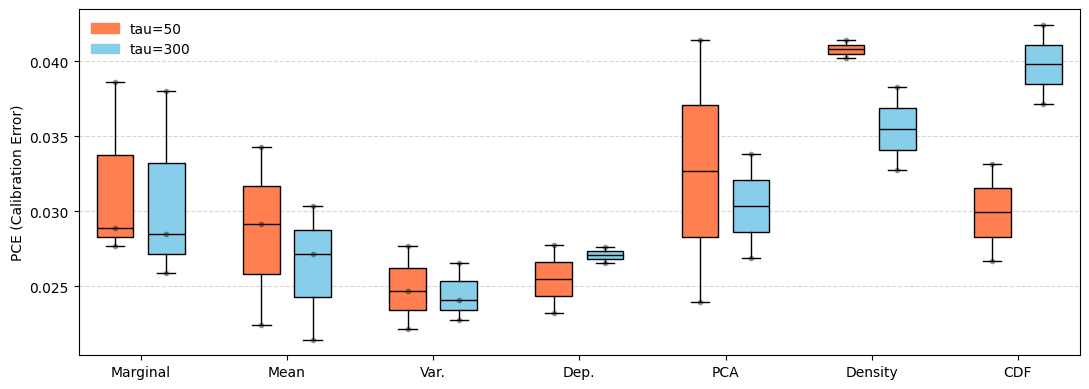

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Load data
df = pd.read_csv('csv-files/sensitivity-t.csv')

# Unique preranks and tau values
preranks = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
labels = ["Marginal", "Mean", "Var.", "Dep.", "PCA", "Density", "CDF"]
taus = [50, 300]  # Comparing extremes for ablation

gap = 2.0      # space between prerank groups
delta = 0.7    # spacing between tau values

data = []
positions = []
xticks = []

for i, p in enumerate(preranks):
    base = i * gap
    xticks.append(base + delta / 2)
    for j, t in enumerate(taus):
        positions.append(base + j * delta)
        val = df[(df['prerank'] == p) & (df['tau'] == t)]['pce'].values
        data.append(val)

plt.figure(figsize=(11, 4))
box = plt.boxplot(data, positions=positions, widths=0.5, patch_artist=True, zorder=2,
                  flierprops=dict(marker='o', markersize=3, alpha=0.3),
                  medianprops=dict(color='black'))

colors = ["coral", "skyblue"]
for i, patch in enumerate(box['boxes']):
    patch.set_facecolor(colors[i % len(taus)])

# Scatter points
for i, d in enumerate(data):
    plt.scatter([positions[i]] * len(d), d, color='black', s=10, zorder=3, alpha=0.3)

plt.xticks(xticks, labels)
plt.ylabel("PCE (Calibration Error)")
plt.legend(handles=[mpatches.Patch(color=colors[0], label='tau=50'),
                   mpatches.Patch(color=colors[1], label='tau=300')],
           loc='upper left', frameon=False)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("tau_sensitivity_ablation_pce.pdf", dpi=300)

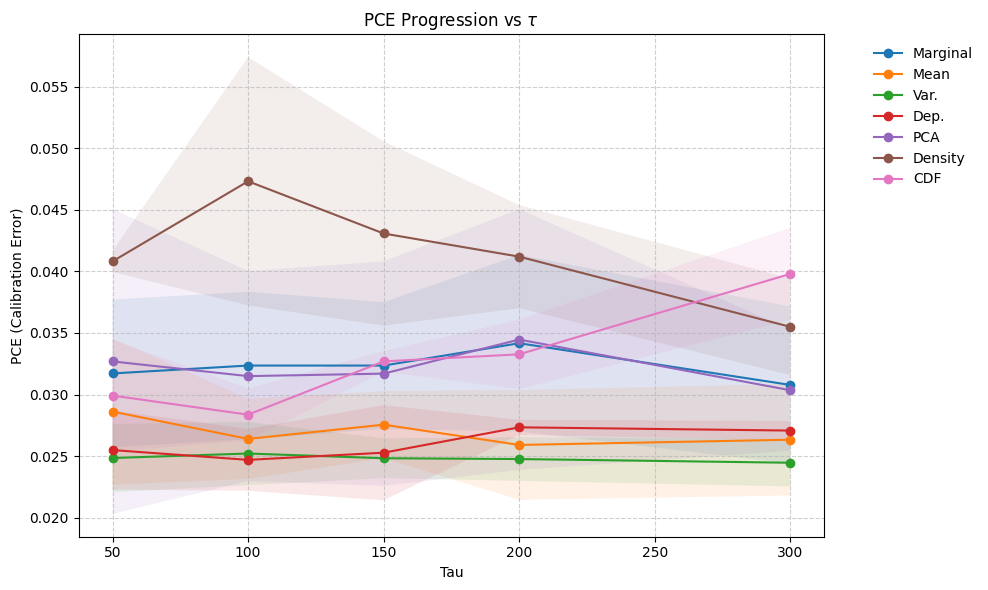

In [62]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load data from the correct path
df = pd.read_csv('csv-files/sensitivity-t.csv')

# Unique preranks and their display labels
preranks = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
labels = ["Marginal", "Mean", "Var.", "Dep.", "PCA", "Density", "CDF"]
prerank_to_label = dict(zip(preranks, labels))

# Group by tau and prerank to get mean and std across datasets
grouped = df.groupby(['tau', 'prerank'])['pce'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(10, 6))

for p in preranks:
    data = grouped[grouped['prerank'] == p]
    plt.plot(data['tau'], data['mean'], marker='o', label=prerank_to_label[p])
    # Shaded area for variance across datasets
    plt.fill_between(data['tau'], data['mean'] - data['std'], data['mean'] + data['std'], alpha=0.1)

plt.xlabel("Tau")
plt.ylabel("PCE (Calibration Error)")
plt.title("PCE Progression vs $\\tau$")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

plt.savefig("tau_progression_pce.pdf", dpi=300)

Plot saved as model_comparison_boxplot.png


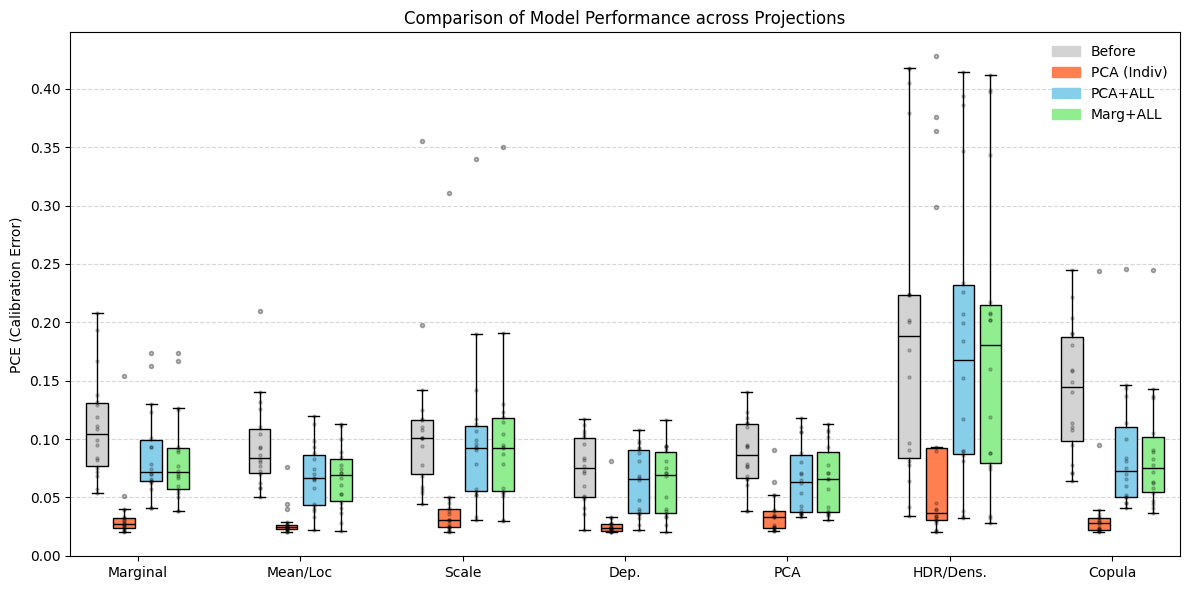

In [63]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Data from snippets
PCA_ALL_LATEX = r"""
air       & $0.144\,(0.002)$ & $0.081\,(0.003)$ & $0.048\,(0.001)$ & $0.093\,(0.002)$ & $0.088\,(0.002)$ & $0.071\,(0.001)$ & $0.190\,(0.003)$ \\
ansur2    & $0.070\,(0.003)$ & $0.152\,(0.002)$ & $0.092\,(0.003)$ & $0.064\,(0.002)$ & $0.066\,(0.002)$ & $0.062\,(0.002)$ & $0.092\,(0.003)$ \\
bio       & $0.041\,(0.002)$ & $0.038\,(0.001)$ & $0.040\,(0.001)$ & $0.041\,(0.001)$ & $0.022\,(0.001)$ & $0.033\,(0.001)$ & $0.033\,(0.001)$ \\
births1   & $0.060\,(0.002)$ & $0.184\,(0.003)$ & $0.092\,(0.002)$ & $0.070\,(0.002)$ & $0.070\,(0.002)$ & $0.070\,(0.001)$ & $0.091\,(0.002)$ \\
births2   & $0.114\,(0.003)$ & $0.386\,(0.003)$ & $0.065\,(0.002)$ & $0.174\,(0.003)$ & $0.038\,(0.002)$ & $0.106\,(0.003)$ & $0.057\,(0.002)$ \\
blog_data & $0.045\,(0.002)$ & $0.199\,(0.003)$ & $0.108\,(0.003)$ & $0.079\,(0.002)$ & $0.058\,(0.002)$ & $0.054\,(0.002)$ & $0.107\,(0.003)$ \\
calcofi   & $0.050\,(0.002)$ & $0.032\,(0.001)$ & $0.032\,(0.001)$ & $0.041\,(0.001)$ & $0.033\,(0.001)$ & $0.037\,(0.001)$ & $0.031\,(0.001)$ \\
house     & $0.100\,(0.002)$ & $0.117\,(0.003)$ & $0.098\,(0.002)$ & $0.101\,(0.002)$ & $0.120\,(0.002)$ & $0.110\,(0.002)$ & $0.093\,(0.002)$ \\
households& $0.146\,(0.003)$ & $0.090\,(0.002)$ & $0.022\,(0.001)$ & $0.093\,(0.002)$ & $0.093\,(0.002)$ & $0.065\,(0.002)$ & $0.117\,(0.003)$ \\
meps_19  & $0.050\,(0.002)$ & $0.226\,(0.003)$ & $0.038\,(0.002)$ & $0.064\,(0.002)$ & $0.044\,(0.002)$ & $0.036\,(0.002)$ & $0.055\,(0.003)$ \\
meps_20  & $0.045\,(0.002)$ & $0.234\,(0.003)$ & $0.036\,(0.002)$ & $0.066\,(0.002)$ & $0.040\,(0.002)$ & $0.036\,(0.002)$ & $0.052\,(0.003)$ \\
meps_21  & $0.052\,(0.002)$ & $0.207\,(0.003)$ & $0.036\,(0.002)$ & $0.062\,(0.002)$ & $0.043\,(0.002)$ & $0.039\,(0.002)$ & $0.052\,(0.003)$ \\
scm1d     & $0.066\,(0.002)$ & $0.090\,(0.002)$ & $0.088\,(0.002)$ & $0.057\,(0.002)$ & $0.067\,(0.002)$ & $0.043\,(0.002)$ & $0.099\,(0.003)$ \\
scm20d    & $0.075\,(0.002)$ & $0.086\,(0.002)$ & $0.067\,(0.002)$ & $0.070\,(0.002)$ & $0.074\,(0.002)$ & $0.036\,(0.001)$ & $0.142\,(0.003)$ \\
scpf      & $0.084\,(0.003)$ & $0.347\,(0.003)$ & $0.068\,(0.003)$ & $0.123\,(0.003)$ & $0.098\,(0.003)$ & $0.106\,(0.003)$ & $0.113\,(0.003)$ \\
taxi      & $0.081\,(0.002)$ & $0.034\,(0.001)$ & $0.081\,(0.002)$ & $0.074\,(0.002)$ & $0.065\,(0.002)$ & $0.080\,(0.002)$ & $0.079\,(0.002)$ \\
wage      & $0.137\,(0.003)$ & $0.414\,(0.003)$ & $0.097\,(0.003)$ & $0.130\,(0.003)$ & $0.083\,(0.003)$ & $0.118\,(0.003)$ & $0.096\,(0.003)$ \\
wq        & $0.246\,(0.003)$ & $0.394\,(0.003)$ & $0.026\,(0.001)$ & $0.163\,(0.003)$ & $0.113\,(0.003)$ & $0.088\,(0.003)$ & $0.340\,(0.003)$ \\
"""

MARGINAL_ALL_LATEX = r"""
air       & $0.143\,(0.002)$ & $0.074\,(0.002)$ & $0.050\,(0.001)$ & $0.091\,(0.002)$ & $0.085\,(0.003)$ & $0.071\,(0.002)$ & $0.191\,(0.003)$ \\
ansur2    & $0.078\,(0.003)$ & $0.160\,(0.002)$ & $0.094\,(0.003)$ & $0.067\,(0.002)$ & $0.071\,(0.002)$ & $0.066\,(0.002)$ & $0.095\,(0.003)$ \\
bio       & $0.041\,(0.002)$ & $0.032\,(0.001)$ & $0.036\,(0.001)$ & $0.038\,(0.001)$ & $0.021\,(0.001)$ & $0.031\,(0.001)$ & $0.030\,(0.001)$ \\
births1   & $0.063\,(0.002)$ & $0.202\,(0.003)$ & $0.094\,(0.002)$ & $0.070\,(0.002)$ & $0.071\,(0.002)$ & $0.071\,(0.001)$ & $0.093\,(0.002)$ \\
births2   & $0.105\,(0.002)$ & $0.397\,(0.003)$ & $0.071\,(0.002)$ & $0.174\,(0.002)$ & $0.041\,(0.002)$ & $0.108\,(0.003)$ & $0.058\,(0.002)$ \\
blog_data & $0.037\,(0.002)$ & $0.202\,(0.003)$ & $0.116\,(0.003)$ & $0.077\,(0.002)$ & $0.061\,(0.002)$ & $0.057\,(0.002)$ & $0.115\,(0.003)$ \\
calcofi   & $0.047\,(0.002)$ & $0.028\,(0.001)$ & $0.033\,(0.001)$ & $0.038\,(0.001)$ & $0.028\,(0.001)$ & $0.037\,(0.001)$ & $0.031\,(0.001)$ \\
house     & $0.091\,(0.002)$ & $0.119\,(0.003)$ & $0.091\,(0.002)$ & $0.093\,(0.002)$ & $0.113\,(0.002)$ & $0.102\,(0.002)$ & $0.087\,(0.002)$ \\
households& $0.137\,(0.002)$ & $0.088\,(0.002)$ & $0.020\,(0.001)$ & $0.089\,(0.002)$ & $0.089\,(0.002)$ & $0.066\,(0.002)$ & $0.123\,(0.002)$ \\
meps_19  & $0.058\,(0.002)$ & $0.217\,(0.003)$ & $0.040\,(0.002)$ & $0.060\,(0.002)$ & $0.053\,(0.002)$ & $0.042\,(0.002)$ & $0.055\,(0.002)$ \\
meps_20  & $0.044\,(0.002)$ & $0.207\,(0.003)$ & $0.033\,(0.002)$ & $0.054\,(0.002)$ & $0.037\,(0.002)$ & $0.034\,(0.002)$ & $0.051\,(0.002)$ \\
meps_21  & $0.054\,(0.002)$ & $0.208\,(0.003)$ & $0.038\,(0.002)$ & $0.056\,(0.002)$ & $0.045\,(0.002)$ & $0.035\,(0.002)$ & $0.054\,(0.003)$ \\
scm1d     & $0.062\,(0.002)$ & $0.077\,(0.002)$ & $0.075\,(0.002)$ & $0.050\,(0.002)$ & $0.053\,(0.002)$ & $0.038\,(0.002)$ & $0.104\,(0.003)$ \\
scm20d    & $0.072\,(0.002)$ & $0.088\,(0.002)$ & $0.068\,(0.002)$ & $0.068\,(0.002)$ & $0.074\,(0.002)$ & $0.037\,(0.001)$ & $0.130\,(0.003)$ \\
scpf      & $0.089\,(0.003)$ & $0.343\,(0.003)$ & $0.071\,(0.003)$ & $0.125\,(0.003)$ & $0.100\,(0.003)$ & $0.106\,(0.003)$ & $0.119\,(0.003)$ \\
taxi      & $0.083\,(0.002)$ & $0.034\,(0.001)$ & $0.081\,(0.002)$ & $0.073\,(0.002)$ & $0.067\,(0.002)$ & $0.078\,(0.002)$ & $0.079\,(0.002)$ \\
wage      & $0.135\,(0.003)$ & $0.412\,(0.003)$ & $0.093\,(0.003)$ & $0.127\,(0.003)$ & $0.078\,(0.003)$ & $0.113\,(0.003)$ & $0.092\,(0.003)$ \\
wq        & $0.245\,(0.003)$ & $0.399\,(0.003)$ & $0.026\,(0.001)$ & $0.167\,(0.003)$ & $0.111\,(0.003)$ & $0.093\,(0.003)$ & $0.350\,(0.003)$ \\
"""

AFTER_LATEX = r"""
households & $0.030\,(0.001)$ & $0.024\,(0.002)$ & $0.021\,(0.002)$ & $0.021\,(0.003)$ & $0.026\,(0.001)$ & $0.039\,(0.003)$ & $0.031\,(0.001)$ \\
air        & $0.040\,(0.001)$ & $0.026\,(0.002)$ & $0.027\,(0.001)$ & $0.027\,(0.002)$ & $0.039\,(0.002)$ & $0.045\,(0.005)$ & $0.029\,(0.001)$ \\
births1    & $0.028\,(0.001)$ & $0.027\,(0.002)$ & $0.031\,(0.002)$ & $0.027\,(0.002)$ & $0.034\,(0.000)$ & $0.034\,(0.003)$ & $0.027\,(0.001)$ \\
births2    & $0.031\,(0.002)$ & $0.029\,(0.002)$ & $0.045\,(0.002)$ & $0.032\,(0.001)$ & $0.052\,(0.006)$ & $0.428\,(0.002)$ & $0.033\,(0.002)$ \\
wage       & $0.051\,(0.020)$ & $0.044\,(0.013)$ & $0.025\,(0.001)$ & $0.024\,(0.002)$ & $0.052\,(0.008)$ & $0.364\,(0.012)$ & $0.095\,(0.015)$ \\
scm20d     & $0.033\,(0.002)$ & $0.025\,(0.001)$ & $0.038\,(0.003)$ & $0.022\,(0.002)$ & $0.033\,(0.001)$ & $0.093\,(0.003)$ & $0.029\,(0.001)$ \\
scm1d      & $0.025\,(0.001)$ & $0.024\,(0.002)$ & $0.036\,(0.003)$ & $0.020\,(0.002)$ & $0.035\,(0.001)$ & $0.090\,(0.015)$ & $0.036\,(0.007)$ \\
wq         & $0.154\,(0.007)$ & $0.076\,(0.010)$ & $0.311\,(0.018)$ & $0.028\,(0.003)$ & $0.091\,(0.004)$ & $0.376\,(0.026)$ & $0.244\,(0.001)$ \\
scpf       & $0.039\,(0.002)$ & $0.026\,(0.003)$ & $0.041\,(0.005)$ & $0.081\,(0.005)$ & $0.063\,(0.004)$ & $0.299\,(0.010)$ & $0.032\,(0.006)$ \\
meps21     & $0.026\,(0.001)$ & $0.025\,(0.001)$ & $0.031\,(0.001)$ & $0.024\,(0.001)$ & $0.025\,(0.001)$ & $0.032\,(0.001)$ & $0.023\,(0.001)$ \\
meps19     & $0.026\,(0.002)$ & $0.023\,(0.001)$ & $0.050\,(0.002)$ & $0.025\,(0.002)$ & $0.024\,(0.001)$ & $0.031\,(0.001)$ & $0.022\,(0.001)$ \\
meps20     & $0.024\,(0.001)$ & $0.023\,(0.001)$ & $0.049\,(0.001)$ & $0.033\,(0.001)$ & $0.024\,(0.000)$ & $0.034\,(0.005)$ & $0.024\,(0.001)$ \\
house      & $0.027\,(0.003)$ & $0.020\,(0.001)$ & $0.025\,(0.003)$ & $0.020\,(0.001)$ & $0.033\,(0.004)$ & $0.028\,(0.002)$ & $0.021\,(0.000)$ \\
bio        & $0.021\,(0.001)$ & $0.020\,(0.001)$ & $0.021\,(0.001)$ & $0.021\,(0.001)$ & $0.021\,(0.001)$ & $0.021\,(0.001)$ & $0.021\,(0.001)$ \\
blogdata   & $0.023\,(0.001)$ & $0.024\,(0.000)$ & $0.023\,(0.001)$ & $0.023\,(0.001)$ & $0.025\,(0.000)$ & $0.030\,(0.001)$ & $0.024\,(0.001)$ \\
calcofi    & $0.020\,(0.000)$ & $0.021\,(0.000)$ & $0.020\,(0.000)$ & $0.020\,(0.000)$ & $0.021\,(0.000)$ & $0.020\,(0.000)$ & $0.020\,(0.000)$ \\
ansur2     & $0.032\,(0.004)$ & $0.040\,(0.009)$ & $0.031\,(0.004)$ & $0.025\,(0.003)$ & $0.038\,(0.003)$ & $0.040\,(0.015)$ & $0.039\,(0.009)$ \\
taxi       & $0.021\,(0.001)$ & $0.022\,(0.001)$ & $0.025\,(0.000)$ & $0.023\,(0.001)$ & $0.022\,(0.001)$ & $0.022\,(0.000)$ & $0.022\,(0.001)$ \\
"""

BEFORE_LATEX = r"""
households & $0.095\,(0.004)$ & $0.092\,(0.002)$ & $0.125\,(0.006)$ & $0.022\,(0.002)$ & $0.066\,(0.002)$ & $0.097\,(0.007)$ & $0.149\,(0.011)$ \\
air        & $0.099\,(0.002)$ & $0.093\,(0.003)$ & $0.198\,(0.005)$ & $0.060\,(0.003)$ & $0.077\,(0.001)$ & $0.081\,(0.007)$ & $0.158\,(0.004)$ \\
births1    & $0.084\,(0.003)$ & $0.086\,(0.003)$ & $0.110\,(0.006)$ & $0.112\,(0.006)$ & $0.079\,(0.002)$ & $0.200\,(0.011)$ & $0.071\,(0.003)$ \\
births2    & $0.193\,(0.008)$ & $0.050\,(0.004)$ & $0.068\,(0.002)$ & $0.071\,(0.002)$ & $0.123\,(0.006)$ & $0.418\,(0.018)$ & $0.204\,(0.031)$ \\
wage       & $0.129\,(0.001)$ & $0.082\,(0.002)$ & $0.101\,(0.004)$ & $0.102\,(0.004)$ & $0.114\,(0.003)$ & $0.417\,(0.005)$ & $0.140\,(0.003)$ \\
scm20d     & $0.072\,(0.001)$ & $0.077\,(0.002)$ & $0.142\,(0.004)$ & $0.077\,(0.007)$ & $0.038\,(0.001)$ & $0.091\,(0.003)$ & $0.078\,(0.001)$ \\
scm1d      & $0.054\,(0.003)$ & $0.058\,(0.005)$ & $0.108\,(0.002)$ & $0.084\,(0.009)$ & $0.038\,(0.001)$ & $0.078\,(0.004)$ & $0.064\,(0.004)$ \\
wq         & $0.167\,(0.005)$ & $0.104\,(0.003)$ & $0.355\,(0.008)$ & $0.036\,(0.001)$ & $0.093\,(0.001)$ & $0.405\,(0.007)$ & $0.245\,(0.001)$ \\
scpf       & $0.208\,(0.009)$ & $0.210\,(0.013)$ & $0.117\,(0.003)$ & $0.073\,(0.006)$ & $0.140\,(0.005)$ & $0.379\,(0.015)$ & $0.222\,(0.019)$ \\
meps21     & $0.119\,(0.002)$ & $0.132\,(0.002)$ & $0.056\,(0.003)$ & $0.050\,(0.004)$ & $0.110\,(0.005)$ & $0.202\,(0.006)$ & $0.181\,(0.006)$ \\
meps19     & $0.132\,(0.004)$ & $0.140\,(0.005)$ & $0.059\,(0.002)$ & $0.049\,(0.002)$ & $0.114\,(0.004)$ & $0.223\,(0.009)$ & $0.190\,(0.006)$ \\
meps20     & $0.111\,(0.004)$ & $0.110\,(0.007)$ & $0.054\,(0.001)$ & $0.041\,(0.001)$ & $0.095\,(0.004)$ & $0.223\,(0.007)$ & $0.159\,(0.005)$ \\
house      & $0.109\,(0.002)$ & $0.126\,(0.002)$ & $0.101\,(0.001)$ & $0.107\,(0.001)$ & $0.118\,(0.002)$ & $0.153\,(0.003)$ & $0.110\,(0.002)$ \\
bio        & $0.057\,(0.002)$ & $0.058\,(0.005)$ & $0.044\,(0.002)$ & $0.051\,(0.002)$ & $0.061\,(0.003)$ & $0.034\,(0.002)$ & $0.108\,(0.005)$ \\
blogdata   & $0.138\,(0.002)$ & $0.062\,(0.002)$ & $0.116\,(0.004)$ & $0.117\,(0.004)$ & $0.068\,(0.001)$ & $0.224\,(0.003)$ & $0.191\,(0.006)$ \\
calcofi    & $0.075\,(0.000)$ & $0.080\,(0.001)$ & $0.078\,(0.000)$ & $0.082\,(0.000)$ & $0.076\,(0.000)$ & $0.064\,(0.001)$ & $0.114\,(0.001)$ \\
ansur2     & $0.068\,(0.004)$ & $0.070\,(0.006)$ & $0.101\,(0.006)$ & $0.104\,(0.006)$ & $0.066\,(0.004)$ & $0.176\,(0.011)$ & $0.071\,(0.005)$ \\
taxi       & $0.082\,(0.001)$ & $0.073\,(0.001)$ & $0.094\,(0.003)$ & $0.096\,(0.003)$ & $0.094\,(0.002)$ & $0.042\,(0.001)$ & $0.095\,(0.002)$ \\
"""

def parse_pce(latex_str):
    res = []
    lines = latex_str.strip().split('\n')
    for line in lines:
        if '&' in line:
            # Extract numbers after & and before ( or \,
            matches = re.findall(r'&\s*\$?\s*(\d+\.\d+)', line)
            res.append([float(m) for m in matches])
    return np.array(res)

# Parse tables
# Order in PCA_ALL/MARGINAL_ALL: Copula, Density, Dep, Marg, Mean, PCA, Scale
# Order in BEFORE/AFTER: Marg, Loc, Scale, Dep, PCA, HDR, Copula

data_pca_all = parse_pce(PCA_ALL_LATEX)
data_marg_all = parse_pce(MARGINAL_ALL_LATEX)
data_after = parse_pce(AFTER_LATEX)
data_before = parse_pce(BEFORE_LATEX)

# Map to consistent order: Marginal, Mean/Loc, Scale, Dep, PCA, HDR/Density, Copula
# Mapping for PCA_ALL/MARGINAL_ALL: 3, 4, 6, 2, 5, 1, 0
idx_map_all = [3, 4, 6, 2, 5, 1, 0]
# Mapping for BEFORE/AFTER: 0, 1, 2, 3, 4, 5, 6
idx_map_ba = [0, 1, 2, 3, 4, 5, 6]

labels = ["Marginal", "Mean/Loc", "Scale", "Dep.", "PCA", "HDR/Dens.", "Copula"]
models = ["Before", "PCA (Indiv)", "PCA+ALL", "Marg+ALL"]
colors = ["lightgrey", "coral", "skyblue", "lightgreen"]

plt.figure(figsize=(12, 6))

gap = 3.0
delta = 0.5
positions = []
xticks = []
plot_data = []

for i in range(7):
    base = i * gap
    xticks.append(base + 1.5 * delta)

    # Extract data for this projection across 4 models
    d_before = data_before[:, idx_map_ba[i]]
    d_after = data_after[:, idx_map_ba[i]]
    d_pca_all = data_pca_all[:, idx_map_all[i]]
    d_marg_all = data_marg_all[:, idx_map_all[i]]

    plot_data.extend([d_before, d_after, d_pca_all, d_marg_all])
    positions.extend([base, base + delta, base + 2*delta, base + 3*delta])

box = plt.boxplot(plot_data, positions=positions, widths=0.4, patch_artist=True, zorder=2,
                  flierprops=dict(marker='o', markersize=3, alpha=0.3),
                  medianprops=dict(color='black'))

for i, patch in enumerate(box['boxes']):
    patch.set_facecolor(colors[i % 4])

# Scatter points
for i, d in enumerate(plot_data):
    plt.scatter([positions[i]] * len(d), d, color='black', s=5, zorder=3, alpha=0.2)

plt.xticks(xticks, labels)
plt.ylabel("PCE (Calibration Error)")
plt.title("Comparison of Model Performance across Projections")

legend_patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(4)]
plt.legend(handles=legend_patches, loc='upper right', frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("model_comparison_boxplot.png", dpi=300)
print("Plot saved as model_comparison_boxplot.png")

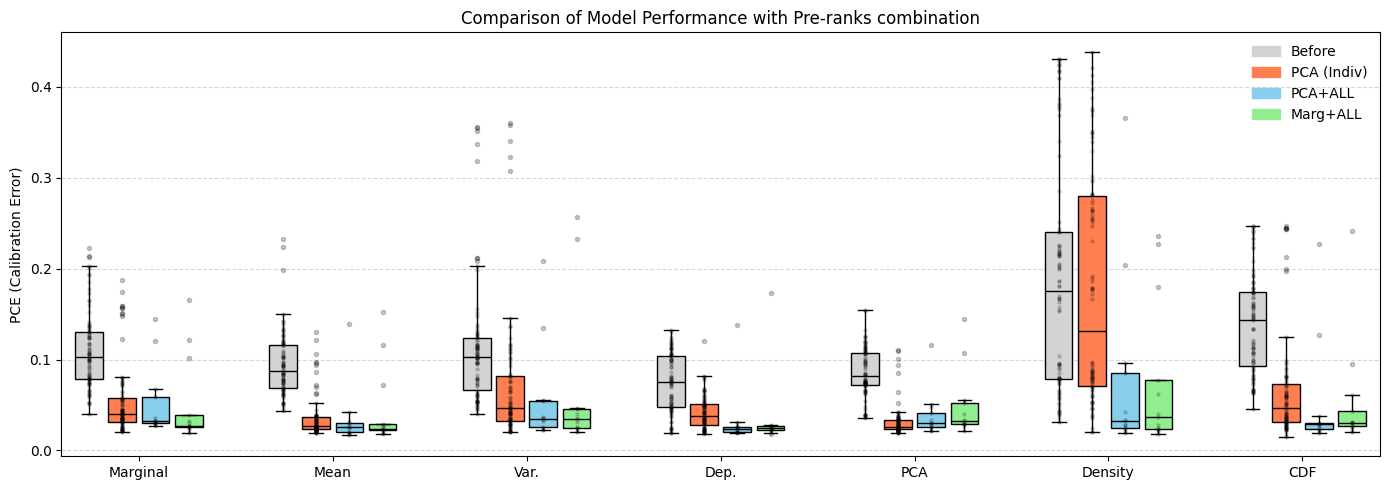

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import os

# Define paths relative to the Multicalibration/Projected_PIT_calibration directory
# If running from the notebook, adjust base_path if needed
base_path = 'csv-files'
final_results_path = os.path.join(base_path, 'FINAL-results')

csv_files = {
    "Before": os.path.join(base_path, 'metrics-from-model-without-reg.csv'),
    "PCA (Indiv)": os.path.join(final_results_path, 'metrics_pca_lambda=10.csv'),
    "PCA+ALL": os.path.join(final_results_path, 'metrics_PCA+ALL_lambda=10.csv'),
    "Marg+ALL": os.path.join(final_results_path, 'metrics_marginal+ALL_lambda=10.csv')
}

# Projection methods to compare
projections = ['marginal', 'mean', 'variance', 'dependency', 'pca', 'density', 'cdf']
labels = ["Marginal", "Mean", "Var.", "Dep.", "PCA", "Density", "CDF"]
models = ["Before", "PCA (Indiv)", "PCA+ALL", "Marg+ALL"]
colors = ["lightgrey", "coral", "skyblue", "lightgreen"]

# Load data
dfs = {}
for model_name, path in csv_files.items():
    if os.path.exists(path):
        dfs[model_name] = pd.read_csv(path)
    else:
        print(f"Warning: {path} not found.")

plt.figure(figsize=(14, 5))

gap = 3.5
delta = 0.6
positions = []
xticks = []
plot_data = []

for i, proj in enumerate(projections):
    base = i * gap
    xticks.append(base + 1.5 * delta)

    col_name = f"pce_{proj}"

    for j, model in enumerate(models):
        if model in dfs and col_name in dfs[model].columns:
            # Extract PCE values for this projection and model
            data = dfs[model][col_name].dropna().values
            plot_data.append(data)
            positions.append(base + j * delta)
        else:
            # Placeholder for missing data to keep positions aligned
            plot_data.append([])
            positions.append(base + j * delta)

# Create boxplot
box = plt.boxplot(plot_data, positions=positions, widths=0.5, patch_artist=True, zorder=2,
                  flierprops=dict(marker='o', markersize=3, alpha=0.2),
                  medianprops=dict(color='black'))

# Color boxes
for i, patch in enumerate(box['boxes']):
    patch.set_facecolor(colors[i % len(models)])

# Scatter points for individual datasets/seeds
for i, d in enumerate(plot_data):
    if len(d) > 0:
        plt.scatter([positions[i]] * len(d), d, color='black', s=5, zorder=3, alpha=0.15)

plt.xticks(xticks, labels)
plt.ylabel("PCE (Calibration Error)")
plt.title("Comparison of Model Performance with Pre-ranks combination")

legend_patches = [mpatches.Patch(color=colors[i], label=models[i]) for i in range(len(models))]
plt.legend(handles=legend_patches, loc='upper right', frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig("model_comparison_boxplot_preranks_combination.pdf", dpi=300)
plt.show()